# HR Attrition — EDA

**Question:** Is attrition concentrated in specific departments/roles, and is it explained by controllable factors (overtime, pay, tenure) or not?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.shape

(1470, 35)

In [2]:
# Basic shape / types / missing values
df.info()
print('\nMissing values:\n', df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [3]:
# Target class balance
df['Attrition'].value_counts(normalize=True)

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

In [4]:
# Attrition rate by Department
dept_rate = df.groupby('Department')['Attrition'].apply(lambda x: (x=='Yes').mean())
dept_rate.sort_values(ascending=False)

Department
Sales                     0.206278
Human Resources           0.190476
Research & Development    0.138398
Name: Attrition, dtype: float64

In [5]:
# Attrition rate by JobRole
role_rate = df.groupby('JobRole')['Attrition'].apply(lambda x: (x=='Yes').mean())
role_rate.sort_values(ascending=False)

JobRole
Sales Representative         0.397590
Laboratory Technician        0.239382
Human Resources              0.230769
Sales Executive              0.174847
Research Scientist           0.160959
Manufacturing Director       0.068966
Healthcare Representative    0.068702
Manager                      0.049020
Research Director            0.025000
Name: Attrition, dtype: float64

In [6]:
# Overtime vs attrition — likely one of the strongest signals
pd.crosstab(df['OverTime'], df['Attrition'], normalize='index')

Attrition,No,Yes
OverTime,,
No,0.895636,0.104364
Yes,0.694712,0.305288


In [7]:
# Income bands vs attrition
df['IncomeBand'] = pd.qcut(df['MonthlyIncome'], 4, labels=['Low','Mid-Low','Mid-High','High'])
df.groupby('IncomeBand')['Attrition'].apply(lambda x: (x=='Yes').mean())

/var/folders/62/mpynd32x269cw1f77xq8b7pr0000gn/T/ipykernel_3355/4208060025.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('IncomeBand')['Attrition'].apply(lambda x: (x=='Yes').mean())


IncomeBand
Low         0.292683
Mid-Low     0.142077
Mid-High    0.106267
High        0.103261
Name: Attrition, dtype: float64

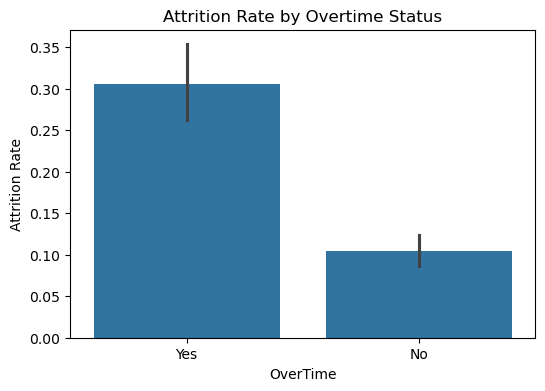

In [8]:
# Visualize the strongest relationship(s) found above
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x='OverTime', y=(df['Attrition']=='Yes').astype(int), data=df, ax=ax)
ax.set_ylabel('Attrition Rate')
ax.set_title('Attrition Rate by Overtime Status')
plt.show()

## Notes / findings so far
- **Overtime is the strongest signal found**: employees working overtime leave at 30.5% vs 10.4% 
  for those who don't — a ~3x gap. This is the single biggest lever in the dataset.
- **Income shows a real but weaker gradient**: lowest income quartile attrits at 29.3% vs 10.3% 
  for the highest quartile.
- **Attrition is concentrated by role, not evenly spread**: Sales Representatives attrit at 39.8%, 
  more than double any other role. Research Director sits at just 2.5%.
- **Sales (20.6%) and HR (19.0%) departments run hotter than R&D (13.8%)** — consistent with the 
  role-level finding since Sales Reps sit in the Sales department.
- No missing values in the dataset — unusual for "real" data, worth noting explicitly since it 
  means less cleaning overhead here than in past projects.
- Next: feature engineering + leakage check (see notebook 02), then modeling.